# **Spoticore Stage 3.0**: _WaveNet_

This notebook is a continuation of the _Stage 2.1_ code.

First, we introduce two new PyTorch-like APIs via the __Embedding__, __Flatten__ and __Sequential__ _Modules_.


### Imports


In [1]:
from typing import Final
import torch
import torch.nn.functional as F
import torch.nn.init as Init
from math import sqrt
from collections.abc import Iterator
from typing import Protocol
from reader import read_all_unique_words
import random

%matplotlib inline
import matplotlib.pyplot as plt

### Constants


In [2]:
SEED: Final[int] = 534150593
N_EMBD: Final[int] = 24
N_HIDDEN: Final[int] = 128

BLOCK_SIZE: Final[int] = 8

### Initialize seed


In [ ]:
torch.manual_seed(SEED)

### Build character-index mappings from training data


In [4]:
type StoiMap = dict[str, int]
type ItosMap = dict[int, str]


def build_vocab_mappings() -> tuple[list[str], StoiMap, ItosMap]:
    words = read_all_unique_words()

    # shuffle up the words
    random.seed(SEED)
    random.shuffle(words)

    chars = sorted(set("".join(words)))

    # create mappings with special token "." at index 0.
    stoi = {char: i + 1 for i, char in enumerate(chars)}
    stoi["."] = 0

    itos = {i: char for char, i in stoi.items()}

    return words, stoi, itos

### Construct model inputs from training data


In [5]:
words, stoi, itos = build_vocab_mappings()
vocab_size = len(stoi)

In [6]:
def construct_model_inputs(
    words: list[str], stoi: StoiMap, block_size: int = 8
) -> tuple[torch.Tensor, torch.Tensor]:
    X, Y = [], []

    for word in words:
        prev_chars_is = [0] * block_size
        for char in word + ".":
            nxt_char_i = stoi[char]
            X.append(prev_chars_is)
            Y.append(nxt_char_i)
            prev_chars_is = prev_chars_is[1:] + [nxt_char_i]
    X, Y = torch.tensor(X), torch.tensor(Y)
    print("X:", X.shape, "Y:", Y.shape)
    return X, Y

### Neural network architecture


In [7]:
class Module(Protocol):
    def __call__(self, x: torch.Tensor) -> torch.Tensor: ...
    def parameters(self) -> Iterator[torch.Tensor]: ...

In [8]:
class Linear:
    def __init__(self, fan_in: int, fan_out: int, bias: bool = True) -> None:
        # Kaiming initialization: scale by 1/√fan_in to maintain unit variance.
        # Gain for non-linearities (e.g., tanh) is applied separately in model setup.
        self.weight = torch.randn((fan_in, fan_out)) / sqrt(fan_in)
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self) -> Iterator[torch.Tensor]:
        yield self.weight
        if self.bias is not None:
            yield self.bias

In [9]:
class BatchNorm1d:
    def __init__(
        self, num_features: int, eps: float = 1e-5, momentum: float = 0.1
    ) -> None:
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # bn gain.
        self.gamma = torch.ones(num_features)
        # bn bias.
        self.beta = torch.zeros(num_features)
        # bn running mean and variance.
        self.running_mean = torch.zeros(num_features)
        self.running_var = torch.ones(num_features)

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        # Forward pass: calculate activations.
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var

        # Normalize to unit variance.
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)

        self.out = self.gamma * xhat + self.beta

        # Update running mean and var.
        if self.training:
            with torch.no_grad():
                self.running_mean = (
                    1 - self.momentum
                ) * self.running_mean + self.momentum * xmean
                self.running_var = (
                    1 - self.momentum
                ) * self.running_var + self.momentum * xvar

        return self.out

    def parameters(self) -> Iterator[torch.Tensor]:
        yield self.gamma
        yield self.beta

In [ ]:
class Embedding:
    def __init__(self, num_embeddings: int, embedding_dim: int = 10) -> None:
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, IX: torch.Tensor) -> torch.Tensor:
        self.out = self.weight[IX]
        # correct dimensions for next module's dot product
        return self.out

    def parameters(self) -> Iterator[torch.Tensor]:
        yield self.weight

In [ ]:
class Flatten:
    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        self.out = x.view(x.shape[0], -1)
        return self.out

    def parameters(self) -> Iterator[torch.Tensor]:
        yield iter(())

In [11]:
class Tanh:
    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        self.out = torch.tanh(x)
        return self.out

    def parameters(self) -> Iterator[torch.Tensor]:
        return iter(())

In [12]:
class Sequential:
    def __init__(self, modules: list[Module]) -> None:
        self.modules = modules

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        for module in self.modules:
            x = module(x)

        self.out = x
        return self.out

    def parameters(self) -> Iterator[torch.Tensor]:
        for module in self.modules:
            yield from module.parameters()

### Create deep MLP


In [ ]:
model = Sequential(
    [  # Input Module.
        Embedding(vocab_size, N_EMBD),
        Flatten(),
        # Hidden Module 1
        Linear(N_EMBD * BLOCK_SIZE, N_HIDDEN),
        BatchNorm1d(N_HIDDEN),
        Tanh(),
        # Hidden Module 2
        Linear(N_HIDDEN, N_HIDDEN),
        BatchNorm1d(N_HIDDEN),
        Tanh(),
        # Hidden Module 3
        Linear(N_HIDDEN, N_HIDDEN),
        BatchNorm1d(N_HIDDEN),
        Tanh(),
        # Output Module
        Linear(N_HIDDEN, vocab_size),
    ]
)

### Kaiming Init for tanh


In [14]:
gain = Init.calculate_gain("tanh")

# Make last module less confident.
with torch.no_grad():
    # If last module is batchnorm.
    # modules[-1].gamma *= 0.1
    # If last module is linear.
    model.modules[-1].weight *= 0.1

    # Apply gain for all tanh pre-activations.
    # Output module does not perform tanh.
    for module in model.modules[:-1]:
        if isinstance(module, Linear):
            module.weight *= gain

### Initialize model parameters for training


In [15]:
params = list(model.parameters())
print("Total parameters: ", sum(p.nelement() for p in params))

# Ensure all parameters take part in backpropagation.
for p in params:
    p.requires_grad = True

Total parameters:  64157


### Split model inputs into datasets


In [16]:
sep1 = int(0.8 * len(words))
sep2 = int(0.9 * len(words))

Xtr, Ytr = construct_model_inputs(words[:sep1], stoi)
Xdev, Ydev = construct_model_inputs(words[sep1:sep2], stoi)
Xte, Yte = construct_model_inputs(words[sep2:], stoi)

X: torch.Size([532190, 8]) Y: torch.Size([532190])
X: torch.Size([66625, 8]) Y: torch.Size([66625])
X: torch.Size([66355, 8]) Y: torch.Size([66355])


First 20 $(\text{input}, \text{output})$ sets:


In [17]:
for x, y in zip(Xtr[:20], Ytr[:20]):
    print("".join(itos[i.item()] for i in x), "-->", itos[y.item()])

........ --> c
.......c --> a
......ca --> r
.....car --> d
....card --> i
...cardi --> o
..cardio --> g
.cardiog --> r
cardiogr --> a
ardiogra --> m
rdiogram --> .
........ --> m
.......m --> i
......mi --> d
.....mid --> o
....mido --> l
...midol --> .
........ --> o
.......o --> s
......os --> w


### Train the model


In [18]:
iterations = 200_000
batch_size = 32
lr = 0.2

# Loss in iterations passed through log10().
losses = []


for i in range(iterations):
    # Construct mini batch of inputs.
    chosen_idxs = torch.randint(0, Xtr.shape[0], (batch_size,))

    # Extract the batches.
    Xb, Yb = Xtr[chosen_idxs], Ytr[chosen_idxs]

    # Forward pass.
    logits = model(Xb)

    loss = F.cross_entropy(logits, Yb)

    # Backward pass.
    for p in params:
        p.grad = None

    loss.backward()

    # Update params.
    lr = 0.2 if i < 150_000 else 0.01
    for p in params:
        if p.grad is not None:
            p.data += -lr * p.grad

    # Track stats.
    if i % 10_000 == 0:
        print(f"{i:7d} / {iterations}: {loss.item():.4f}")

    losses.append(loss.log10().item())


print(f"\nFinal loss: {loss.item():.4f}")

      0 / 200000: 3.6110
  10000 / 200000: 2.3560
  20000 / 200000: 2.4207
  30000 / 200000: 2.1078
  40000 / 200000: 2.0249
  50000 / 200000: 2.3682
  60000 / 200000: 2.1722
  70000 / 200000: 2.4577
  80000 / 200000: 1.9283
  90000 / 200000: 2.0053
 100000 / 200000: 2.3085
 110000 / 200000: 2.2070
 120000 / 200000: 2.0929
 130000 / 200000: 2.0075
 140000 / 200000: 2.1585
 150000 / 200000: 2.0079
 160000 / 200000: 2.2088
 170000 / 200000: 2.1680
 180000 / 200000: 2.0565
 190000 / 200000: 2.3817

Final loss: 2.4632


### Loss vs iteration

We see below that the loss fluctuates every iteration due to mini-batch noise over 200 000 iterations.

Note:

> When we pass a 1D array to `plt.plot()`, it treats the indices (0 to 199) as the X-axis and the averaged loss values as the Y-axis.


Text(0, 0.5, 'Loss')

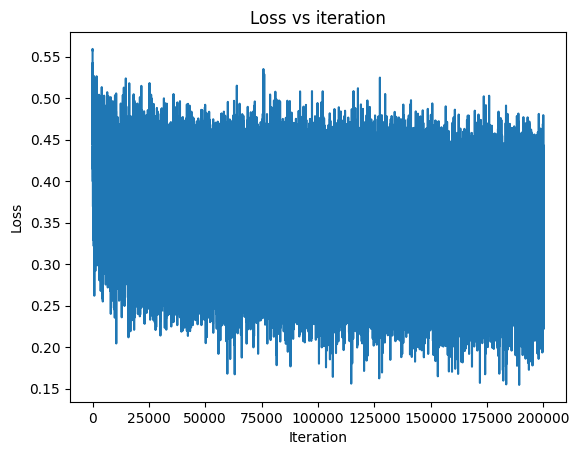

In [23]:
plt.plot(losses)
plt.title("Loss vs iteration")
plt.xlabel("Iteration")
plt.ylabel("Loss")

### Downsampled loss vs iteration

Downsampling is the process of reducing the number of data points in a dataset while trying to preserve the most important information called the _signal_.
In our plot above, the signal is the underlying curve that shows the loss decreasing over time.

There are different methods of downsampling. We will be using _averaging_/_binning_ technique where we calculate `mean()` for every 1000 losses. An alternative technique is _stridding_ where we grab the 1000th loss (`losses[0]`, `losses[1000]`, `losses[2000]`) instead. The mean technique is better because the average of 1000 points is more representative of the 1000 datapoint window than one single random point. In other words, it preserves the _signal_ better.

**Why do we downsample?**

Observe that we cannot infer whether the loss is going down/up (among other possible observations) from the plot above. Downsampling helps to soften the effect of the mini-batch noise and reveals the "skeleton curve" or general trend of the loss.


Text(0, 0.5, 'Loss')

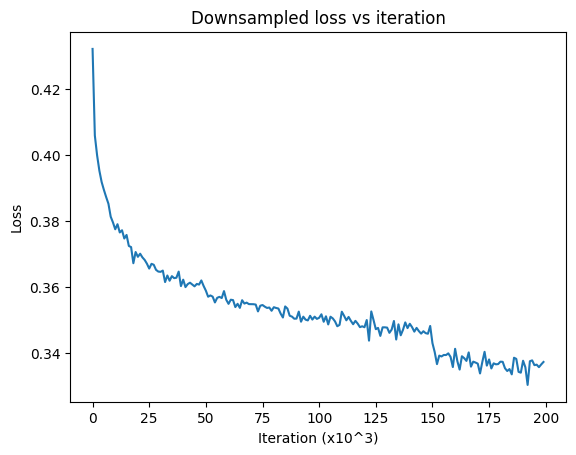

In [24]:
plt.plot(torch.tensor(losses).view(-1, 1000).mean(1))
plt.title("Downsampled loss vs iteration")
plt.xlabel("Iteration (x10^3)")
plt.ylabel("Loss")